<h1 style="text-align: center; font-family: Arial"> TP 1 - Séance 1 </h1>
<h2 style="text-align: center; font-family: Arial"> Qualité d'image </h2>

Équipe #0
- Nom, Prénom (Matricule)
- Nom, Prénom (Matricule)

In [1]:
# Importe les modules qui seront utilisés dans le laboratoire.
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread

%matplotlib inline
# Étend la taille des figures
plt.rcParams["figure.figsize"] = (12, 7)

<span style='color: red;'> Attention : Lisez également le fichier Énoncé TP1.pdf que nous vous donnons. Il contient les questions du TP mais également des informations supplémentaires et astuces pour vous aider.  
</span>

# Exercice I: Étude de la résolution
## Mise en place des fonctions

<span style='color: red;'> Attention : tous les fichiers et les images dont vous aurez besoin pour cette séance sont dans le dossier 'fichiers_seance_1'. Vos chemins devront être ajustés en conséquence. 
</span>

**1.** Ouvrez et affichez l'image ```brain_tumor.jpg```. 

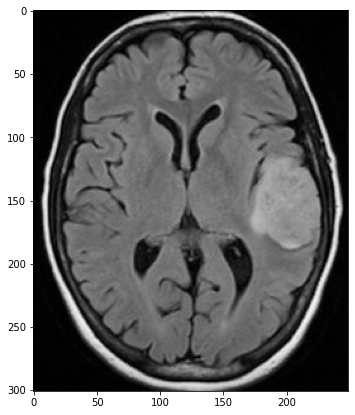

In [2]:
img=plt.imread("brain_tumor.jpg")
plt.imshow(img)

**2.** Déterminez graphiquement la largeur approximative de la tumeur en pixel (selon l'axe transversal).

Affichez cette largeur sous forme d'une ligne pointillée délimitée par deux points, avec la fonction ```ax.plot(x, y)```. 

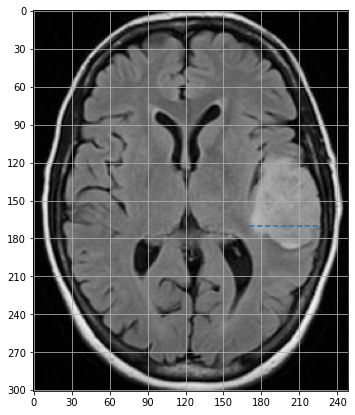

In [3]:
# vous pouvez utiliser ax.imshow(img) puis ax.plot(x, y) pour afficher une image et y superposer des points
# vous pouvez afficher la grille sur l'image avec plt.grid() pour mieux trouver les positions en pixel
fig, ax = plt.subplots()
ax.imshow(img)
ax.set_xticks(np.arange(0, img.shape[1], 30))
ax.set_yticks(np.arange(0, img.shape[0], 30))
ax.grid()
ax.plot([170, 225],[170,170], "--")
# La largeur de la tumeur semble être d'environ 55 pixels

**3.** Définissez la méthode ```taillePixel(x0, y0, x1, y1, ref)``` qui calcule la taille physique d'un pixel en millimètre.

In [17]:
def taille_pixel(x0, y0, x1, y1, ref):
    """Calcule la taille d'un pixel en fonction des coordonnées d'un objet et sa taille de référence
    @param x0  La coordonnée x du point 0
    @param y0  La coordonnée y du point 0
    @param x1  La coordonnée x du point 1
    @param y1  La coordonnée y du point 1
    @param ref La taille physique en mm de l'objet défini par les points 0 et 1
    @return    La taille physique d'un pixel en millimètre
    """
    return ref/np.sqrt((y1-y0)**2+(x1-x0)**2)

**4.** La largeur de la tumeur est de 3 cm. Déduisez la largeur d'un pixel en millimètre.

In [18]:
# taille_pixel(x0,y0,x1,y1,ref)=0, donc
ref = 0.055

**5.** Définissez la méthode ```downsample(img, f)```.

In [19]:
def downsample(img, f):
    """Sous-échantillone l'image img d'un facteur f
    @param img  L'image à sous-échantilloner.
    @param f    Le facteur de sous-échantillonage (un pixel sur f est conservé).
    @return     L'image sous-échantillonée: sa taille est celle d'img divisée par f.
    """
    Img=img[::f, ::f]
    return Img

**6.** Affichez l'image de la tumeur sous-échantillonnée avec ```f=2, 3, 4```. Affichez le facteur de downsampling ainsi que la taille de l'image downsamplée dans le titre de la figure. Comment évolue la largeur d'un pixel lors du sous-échantillonage? Donnez un avantage et un inconvénient de l'utilisation d'une image médicale downsamplée plutôt que l'image pleine résolution. 

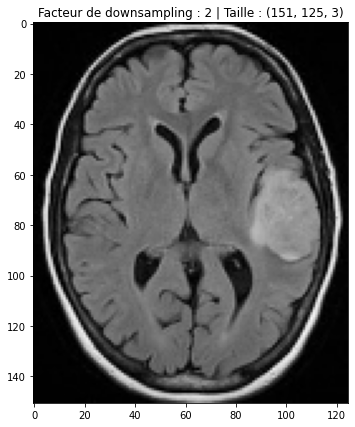

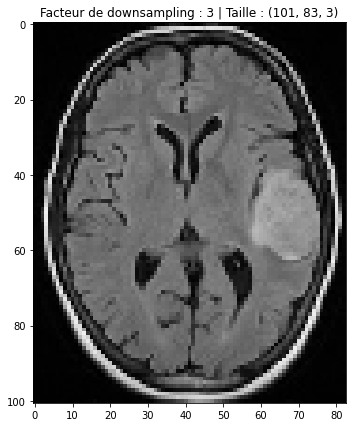

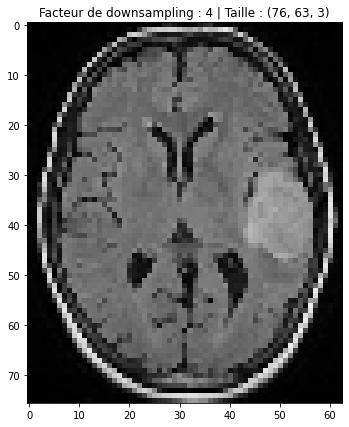

In [20]:
# pour inclure la valeur d'une variable dans un string, vous pouvez utiliser la syntaxe suivante (pour une variable x):
# f"ma variable : {x}"              ou encore
# "ma variable :{:.2f}".format(x)   pour forcer l'affichage à afficher une valeur flottante avec 2 décimales
l = [2, 3, 4]

for i in l:
    Img = downsample(img, i)

    fig, ax = plt.subplots()
    ax.imshow(Img)
    ax.set_title(f"Facteur de downsampling : {i} | Taille : {Img.shape}")
    
    plt.show()

# Il y a moins de pixels donc la taille du pixel augmente avec le facteur de downsampling.
# Cela permet d'avoir des images moins lourdes plus faciles à manier
# Mais cela entraine aussi une perte en netteté et une perte en information

## Calibration d'un IRM

**7.** Ouvrez et affichez l'image ```resolution.png```. Affichez l'image en niveau de gris, cachez les axes et ajoutez un titre. Par dessus l'image, dessinez des lignes pointillées le long des mires verticales et horizontales. Affichez une légende pour les lignes. 

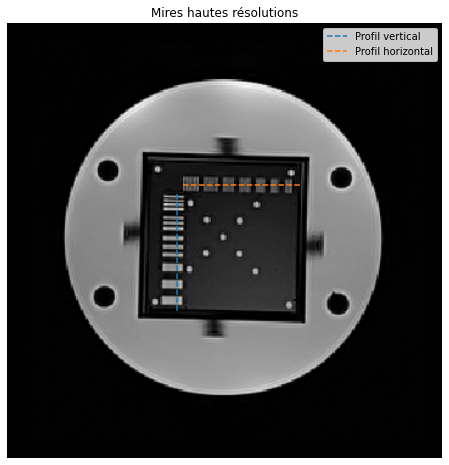

In [28]:
# np.arange, plt.imshow, plt.plot, plt.legend ...
# Pour les deux profils vous pouvez prendre: y=201:341, x=200 et y=190, x=206:346.

# Chargement de l'image
img_resolution = plt.imread("resolution.png")

# Affichage
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(img_resolution, cmap="gray")

# Profil vertical : x = 200, y de 201 à 340
ax.plot([200, 200], [201, 340], "--",
        label="Profil vertical")

# Profil horizontal : y = 190, x de 206 à 345
ax.plot([206, 345], [190, 190], "--",
        label="Profil horizontal")

ax.set_title("Mires hautes résolutions")
ax.legend()
ax.axis("off")

plt.show()


**8.** La largeur du cube central est de 10 cm. Déduisez la largeur d'un pixel en millimètre.

In [22]:
largeur_pixel = taille_pixel(160, 151, 356, 157, 100)

print(f"Largeur d'un pixel : {largeur_pixel:.3f} mm")

Largeur d'un pixel : 0.510 mm


**9.** Quelle est la relation entre la largeur d'un pixel et la taille du plus petit objet observable ? Selon cette relation, quelle serait la taille du plus petit objet observable dans cette image ?



La taille du plus petit objet observable est approximativement égale à deux fois la largeur d'un pixel. La largeur d'un pixel étant d'environ 0,510 mm, le plus petit objet théoriquement observable est donc d'environ 1,02 mm.

**10.** Afin de vérifier cette relation, affichez les profils d'intensités le long d'axes perpendiculaires aux mires. Utilisez la distance en millimètres comme abscisses. 

Quelle est l'épaisseur des plus petites mires observables? Fiez-vous au tableau 1 et à la figure 3 de l'énoncé. 

Est-ce cohérent avec votre réponse donnée à la question **9** ?

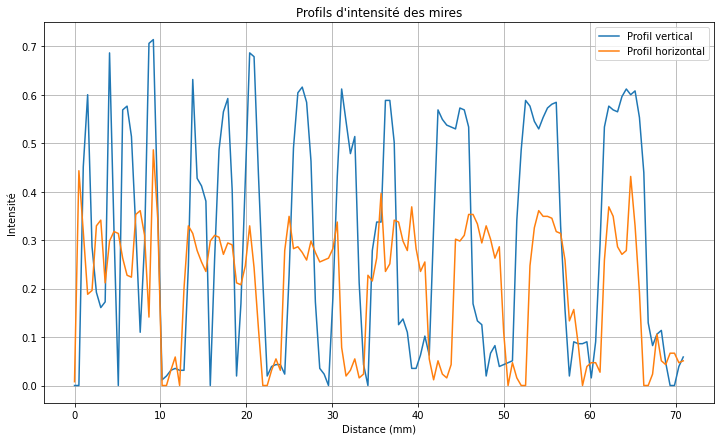

In [26]:
# Extraction des profils
profil_vertical = img_resolution[201:341, 200]
profil_horizontal = img_resolution[190, 206:346]

# Axe des distances en mm
distance_verticale = np.arange(len(profil_vertical)) * largeur_pixel
distance_horizontale = np.arange(len(profil_horizontal)) * largeur_pixel

# Affichage
fig, ax = plt.subplots()

ax.plot(distance_verticale, profil_vertical, label="Profil vertical")
ax.plot(distance_horizontale, profil_horizontal, label="Profil horizontal")

ax.set_xlabel("Distance (mm)")
ax.set_ylabel("Intensité")
ax.set_title("Profils d'intensité des mires")
ax.legend()
ax.grid()

plt.show()

## Mesure de l'épaisseur de coupe

**11.** Affichez les profils d'intensités des 4 rampes et mesurer graphiquement la largeur des gaussiennes à mi-hauteur. 

(Affichez les grilles sur les graphiques et augmenter la fréquence des ticks et la taille de l'image devraient faciliter la mesure).

FWHM rampe 1 = 10.20 mm
FWHM rampe 2 = 11.22 mm
FWHM rampe 3 = 8.67 mm
FWHM rampe 4 = 11.73 mm


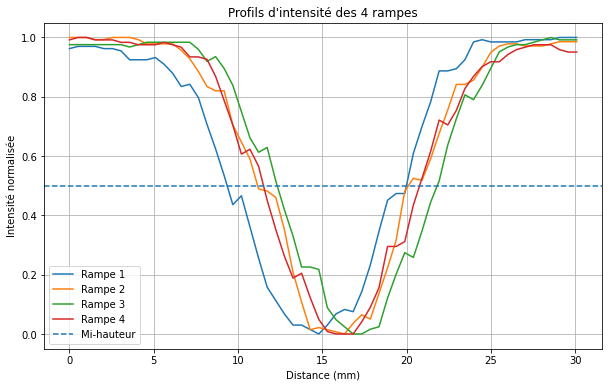

In [37]:
# Pour les profils des rampes vous pouvez prendre: y=140, x=230:290
#                                                  y=230:290, x=365
#                                                  y=360, x=210:270
#                                                  y=215:275, x=147
 

# Extraction des profils
profil1 = img_resolution[140, 230:290]
profil2 = img_resolution[230:290, 365]
profil3 = img_resolution[360, 210:270]
profil4 = img_resolution[215:275, 147]

profils = [profil1, profil2, profil3, profil4]


# Fonction pour calculer la FWHM
def calcul_FWHM(profil, largeur_pixel):

    # Normalisation entre 0 et 1
    profil_norm = (profil - np.min(profil)) / (np.max(profil) - np.min(profil))

    # Position du maximum
    maximum = np.argmax(profil_norm)

    # Recherche vers la gauche du maximum
    gauche = maximum
    while gauche > 0 and profil_norm[gauche] >= 0.5:
        gauche -= 1

    # Recherche vers la droite du maximum
    droite = maximum
    while droite < len(profil_norm)-1 and profil_norm[droite] >= 0.5:
        droite += 1

    # FWHM en mm
    FWHM = (droite - gauche) * largeur_pixel

    return FWHM


# Liste qui contiendra les 4 FWHM
FWHMs = []

fig, ax = plt.subplots(figsize=(10, 6))


for i, profil in enumerate(profils):

    # Normalisation
    profil_norm = (profil - np.min(profil)) / (np.max(profil) - np.min(profil))

    # Axe horizontal en mm
    distance = np.arange(len(profil)) * largeur_pixel

    # Affichage du profil
    ax.plot(distance, profil_norm, label=f"Rampe {i+1}")

    # Calcul de la FWHM
    FWHM = calcul_FWHM(profil, largeur_pixel)
    FWHMs.append(FWHM)

    print(f"FWHM rampe {i+1} = {FWHM:.2f} mm")


# Ligne de mi-hauteur
ax.axhline(0.5, linestyle="--", label="Mi-hauteur")

ax.set_xlabel("Distance (mm)")
ax.set_ylabel("Intensité normalisée")
ax.set_title("Profils d'intensité des 4 rampes")
ax.legend()
ax.grid()

plt.show()

**12.** L'épaisseur de la coupe est donnée par $e=\tan(14^\circ) \times FWHM$ où $FWHM$ est la largeur à mi-hauteur en mm. Sachant que les paramètres de l'IRM indiquent une épaisseur de coupe théorique de $2\pm0.3$ mm, passerait-il le controle qualité?

In [40]:
for i, FWHM in enumerate(FWHMs):

    epaisseur = np.tan(np.deg2rad(14)) * FWHM

    print(f"Rampe {i+1} :")
    print(f"FWHM = {FWHM:.2f} mm")
    print(f"Épaisseur = {epaisseur:.2f} mm")

Rampe 1 :
FWHM = 10.20 mm
Épaisseur = 2.54 mm
Rampe 2 :
FWHM = 11.22 mm
Épaisseur = 2.80 mm
Rampe 3 :
FWHM = 8.67 mm
Épaisseur = 2.16 mm
Rampe 4 :
FWHM = 11.73 mm
Épaisseur = 2.92 mm


# Exercice II: Analyse du contraste et du bruit
## Mesure du contraste

In [56]:
# pour étendre l'affichage des figures encore plus, facultatif !
plt.rcParams["figure.figsize"] = (20, 7)

**1.** Chargez  et affichez l'image ```oct.png```.

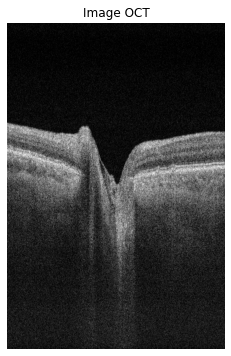

In [73]:
img_oct = plt.imread("oct.png")

fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(img_oct, cmap="gray")
ax.set_title("Image OCT")
ax.axis("off")

plt.show()

**2.** Chargez  et affichez les segmentations ```mask_choroid_left.npy```, ```mask_choroid_right.npy```, ```mask_rpe_left.npy```, ```mask_rpe_right.npy``` et ```mask_onh.npy```.

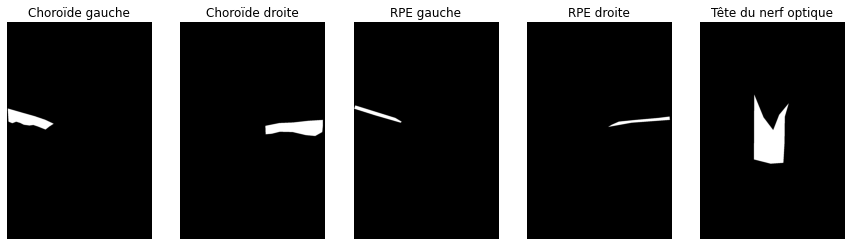

In [58]:
# Chargement des 5 masques
mask_choroid_left = np.load("mask_choroid_left.npy")
mask_choroid_right = np.load("mask_choroid_right.npy")
mask_rpe_left = np.load("mask_rpe_left.npy")
mask_rpe_right = np.load("mask_rpe_right.npy")
mask_onh = np.load("mask_onh.npy")

# Affichage
masks = [mask_choroid_left, mask_choroid_right, mask_rpe_left, mask_rpe_right, mask_onh]

titres = ["Choroïde gauche", "Choroïde droite", "RPE gauche", "RPE droite", "Tête du nerf optique"]

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax, mask, titre in zip(axes, masks, titres):
    ax.imshow(mask, cmap="gray")
    ax.set_title(titre)
    ax.axis("off")

plt.show()

**3.** Regrouper les segmentations de la choroide et de la RPE en un seul masque par région (1 masque pour la choroide, gauche et droite, etc.). Affichez les segmentations regroupées.

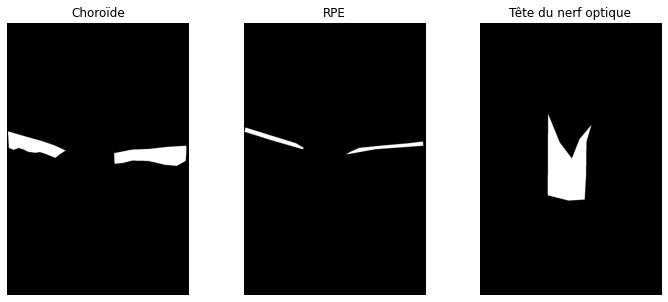

In [59]:
# Regroupement des masques gauche et droite
mask_choroid = np.logical_or(mask_choroid_left, mask_choroid_right)
mask_rpe = np.logical_or(mask_rpe_left, mask_rpe_right)

# Affichage
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(mask_choroid, cmap="gray")
axes[0].set_title("Choroïde")

axes[1].imshow(mask_rpe, cmap="gray")
axes[1].set_title("RPE")

axes[2].imshow(mask_onh, cmap="gray")
axes[2].set_title("Tête du nerf optique")

for ax in axes:
    ax.axis("off")

plt.show()

**4.** Utilisez le masque  ```mask_retina.npy ``` pour définir un masque du fond de l'image (et pas de la rétine).

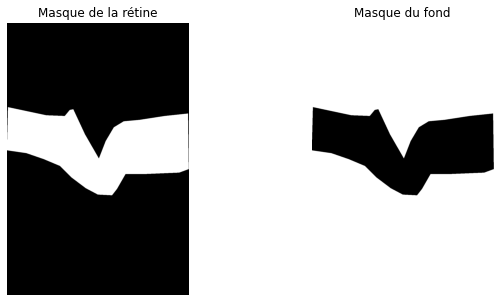

In [60]:
# Chargement du masque de la rétine
mask_retina = np.load("mask_retina.npy")

# Création du masque du fond
mask_background = np.ones_like(mask_retina, dtype=bool)

# Les pixels appartenant à la rétine sont retirés du fond
mask_background[mask_retina.astype(bool)] = 0

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(mask_retina, cmap="gray")
axes[0].set_title("Masque de la rétine")
axes[0].axis("off")

axes[1].imshow(mask_background, cmap="gray")
axes[1].set_title("Masque du fond")
axes[1].axis("off")

plt.show()

**5.** Calculez l'intensité moyenne sur ces 3 régions (choroide, RPE et tête du nerf optique) et sur le fond de l'image. En déduire le contraste entre chaque région et le fond de l'image OCT. Quelle est la zone de la rétine où le contraste est le meilleur ?

In [61]:


# Intensités moyennes
moy_choroid = np.mean(img_oct[mask_choroid])
moy_rpe = np.mean(img_oct[mask_rpe])
moy_onh = np.mean(img_oct[mask_onh])
moy_background = np.mean(img_oct[mask_background])

print("Intensités moyennes :")
print(f"Choroïde : {moy_choroid:.2f}")
print(f"RPE : {moy_rpe:.2f}")
print(f"Tête du nerf optique : {moy_onh:.2f}")
print(f"Fond : {moy_background:.2f}")

# Contrastes avec le fond
contraste_choroid = abs(moy_choroid - moy_background)
contraste_rpe = abs(moy_rpe - moy_background)
contraste_onh = abs(moy_onh - moy_background)

print("\nContrastes avec le fond :")
print(f"Choroïde : {contraste_choroid:.2f}")
print(f"RPE : {contraste_rpe:.2f}")
print(f"Tête du nerf optique : {contraste_onh:.2f}")

# Recherche de la région ayant le meilleur contraste
contrastes = {"Choroïde": contraste_choroid, "RPE": contraste_rpe, "Tête du nerf optique": contraste_onh}

meilleure_region = max(contrastes, key=contrastes.get)

print(f"\nLa région avec le meilleur contraste est : {meilleure_region}")

Intensités moyennes :
Choroïde : 0.48
RPE : 0.70
Tête du nerf optique : 0.03
Fond : 0.09

Contrastes avec le fond :
Choroïde : 0.39
RPE : 0.60
Tête du nerf optique : 0.07

La région avec le meilleur contraste est : RPE


## Mesure du Rapport Contraste/Bruit

**6.** Ouvrez et affichez les images ```oct.png```, ```oct_2.png```,  ```oct_3.png```, ```oct_4.png```, ```oct_5.png```. 

In [62]:
plt.rcParams["figure.figsize"] = (30, 10)

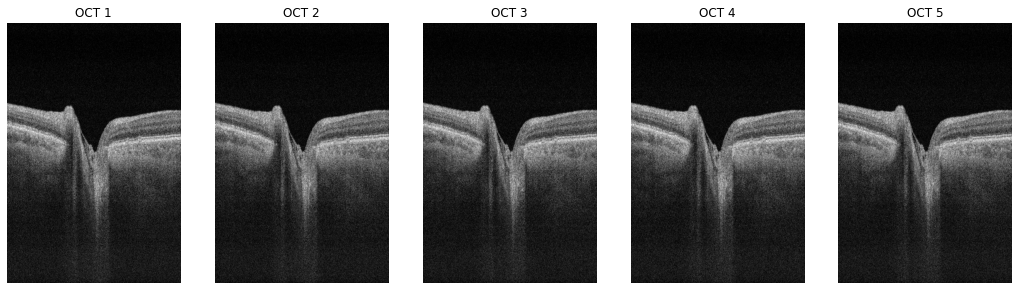

In [63]:

oct1 = plt.imread("oct.png")
oct2 = plt.imread("oct_2.png")
oct3 = plt.imread("oct_3.png")
oct4 = plt.imread("oct_4.png")
oct5 = plt.imread("oct_5.png")

images_oct = [oct1, oct2, oct3, oct4, oct5]

# Affichage
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, image in enumerate(images_oct):
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"OCT {i+1}")
    axes[i].axis("off")

plt.show()

**7.** En utilisant la segmentation de la rétine et la segmentation de la région avec le plus grand contraste (question précédente), calculez le CNR en décibel sur ces 5 images. 

In [68]:
def calcul_CNR(image, mask_cible, mask_fond):

    # Intensité moyenne de la cible
    mu_cible = np.mean(image[mask_cible])

    # Intensité moyenne du fond
    mu_fond = np.mean(image[mask_fond])

    # Écart-type du fond
    sigma_fond = np.std(image[mask_fond])

    # Calcul du CNR
    CNR = abs(mu_cible - mu_fond) / sigma_fond

    # Conversion en décibels
    CNR_dB = 20 * np.log10(CNR)

    return CNR_dB


# Choix du masque de la région ayant le meilleur contraste à la Q5
if meilleure_region == "Choroïde":
    mask_cible = mask_choroid

elif meilleure_region == "RPE":
    mask_cible = mask_rpe

else:
    mask_cible = mask_onh


# Calcul du CNR des 5 images
CNRs = []

for i, image in enumerate(images_oct):

    CNR = calcul_CNR(image, mask_cible, mask_background)
    CNRs.append(CNR)

    print(f"CNR image {i+1} = {CNR:.2f} dB")

CNR image 1 = 15.21 dB
CNR image 2 = 15.18 dB
CNR image 3 = 15.14 dB
CNR image 4 = 15.08 dB
CNR image 5 = 15.12 dB


**8.** Calculer une image moyenne de ces 5 images, qui sera une estimation de l'image OCT débruitée. Affichez côte à côte une des images originale et l'image moyennée. Quelles différences remarquez-vous ?

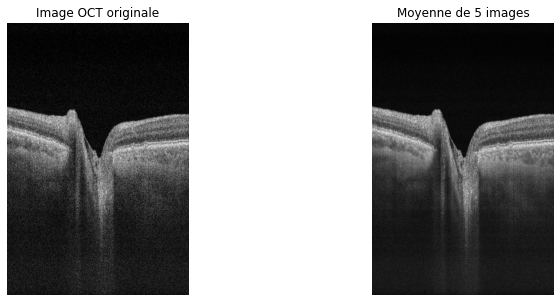

In [69]:

image_moyenne = np.mean(images_oct, axis=0)

# Comparaison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(oct1, cmap="gray")
axes[0].set_title("Image OCT originale")
axes[0].axis("off")

axes[1].imshow(image_moyenne, cmap="gray")
axes[1].set_title("Moyenne de 5 images")
axes[1].axis("off")

plt.show()

**9.** Calculer le CNR sur une des images originales, l'image moyennée calculée à la question précédente, et sur l'image ```ave.png``` fournie. Affichez les trois images côte-à-côte et comparez leurs CNRs. Quelle image obtient le CNR le plus élevé ? 

CNR image originale : 15.21 dB
CNR moyenne des 5 images : 17.02 dB
CNR ave.png : 17.50 dB


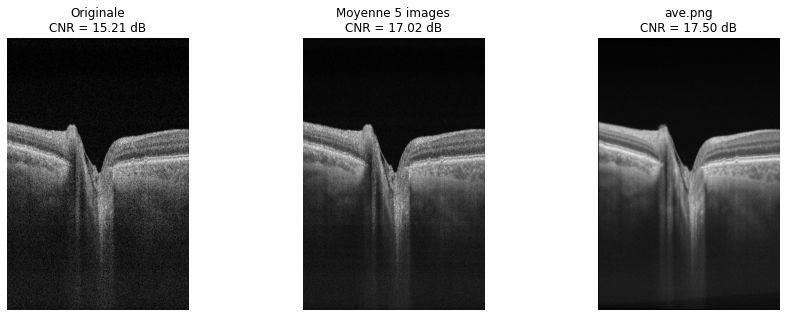

In [70]:


ave = plt.imread("ave.png")

# Calcul des CNR
CNR_original = calcul_CNR(oct1, mask_cible, mask_background)
CNR_moyenne = calcul_CNR(image_moyenne, mask_cible, mask_background)
CNR_ave = calcul_CNR(ave, mask_cible, mask_background)

print(f"CNR image originale : {CNR_original:.2f} dB")
print(f"CNR moyenne des 5 images : {CNR_moyenne:.2f} dB")
print(f"CNR ave.png : {CNR_ave:.2f} dB")

# Affichage
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(oct1, cmap="gray")
axes[0].set_title(f"Originale\nCNR = {CNR_original:.2f} dB")

axes[1].imshow(image_moyenne, cmap="gray")
axes[1].set_title(f"Moyenne 5 images\nCNR = {CNR_moyenne:.2f} dB")

axes[2].imshow(ave, cmap="gray")
axes[2].set_title(f"ave.png\nCNR = {CNR_ave:.2f} dB")

for ax in axes:
    ax.axis("off")

plt.show()

**10.** Que pouvez-vous conclure sur la technique de moyennage comme technique de débruitage ? (Pourriez-vous utiliser la technique de moyennage en tout temps ? Quelles conditions doivent être respectées pour que la technique fonctionne bien ?)

Le moyennage est une technique efficace de débruitage puisque le bruit aléatoire varie entre les différentes acquisitions alors que les structures présentes dans l'image restent similaires. En moyennant plusieurs images, une partie du bruit est donc atténuée. Dans nos résultats, le CNR passe de 15.21 dB pour une image originale à 17.02 dB pour la moyenne de cinq images, ce qui confirme cette amélioration. Cependant, cette méthode ne peut pas être utilisée dans toutes les situations. Les différentes acquisitions doivent notamment être correctement alignées et les structures observées ne doivent pas se déplacer significativement entre les acquisitions. Dans le cas contraire, le moyennage risque de créer du flou et de faire perdre des détails.

**11.** Que représente le rapport contraste/bruit? Est-il préférable d'avoir un CNR faible ou fort? 



Le rapport contraste/bruit (CNR) représente la différence entre le signal d'une région cible et celui du fond relativement au niveau de bruit. Il permet donc d'évaluer à quel point une structure peut être distinguée du fond malgré la présence de bruit. Il est préférable d'avoir un CNR élevé, car la structure cible est alors plus facilement distinguable du fond.

**12.** Nommez un avantage de calculer le rapport contraste/bruit par rapport au rapport signal/bruit. 

Contrairement au SNR, le CNR prend en compte la différence de signal entre la structure étudiée et le fond. Il permet donc de mieux évaluer la capacité à distinguer une structure particulière dans une image bruitée.